In [5]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from arch import arch_model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
import seaborn as sns
warnings.filterwarnings('ignore', category=UserWarning, message='.*DataScaleWarning.*')
warnings.filterwarnings('ignore', category=FutureWarning)

# Set the random seed
seed = 42
np.random.seed(seed)
random.seed(seed)

# Load the dataset
file_path = 'Bitcoinclose.xlsx'
data = pd.read_excel(file_path)
data['date'] = pd.to_datetime(data['date'])
data = data[::-1].reset_index(drop=True)
data.fillna(method='ffill', inplace=True)

# ✅ Compute log returns
data['log_return'] = np.log(data['close'] / data['close'].shift(1))
data.dropna(inplace=True)  # Drop first NA row

# Extract log returns and corresponding price
returns = data['log_return'].values
prices = data['close'].values[1:]  # align with returns

# Split data
train_size = int(len(returns) * 0.8)
train_returns = returns[:train_size]
test_returns = returns[train_size:]
test_prices = prices[train_size + 1:]


# ✅ Fit GARCH(1,1) model on train log returns
model = arch_model(train_returns, vol='Garch', p=1, q=1)
model_fit = model.fit(disp='off')

# ✅ Forecast variance for each day in test set using a rolling forecast
forecasted_returns = []
rolling_window = list(train_returns[-40:])  # use last 40 points as initial window

for i in range(len(test_returns)):
    temp_model = arch_model(rolling_window, vol='Garch', p=1, q=1)
    temp_fit = temp_model.fit(disp='off')
    
    forecast = temp_fit.forecast(horizon=1)
    sigma = np.sqrt(forecast.variance.values[-1, 0])
    
    # Simulate a return using N(0, sigma^2)
    predicted_return = np.random.normal(loc=0, scale=sigma)
    forecasted_returns.append(predicted_return)

    # Append actual return to rolling window for next iteration
    rolling_window.append(test_returns[i])
    if len(rolling_window) > 40:
        rolling_window.pop(0)

# ✅ Reconstruct predicted prices from predicted returns
last_train_price = prices[train_size - 1]
predicted_prices = [last_train_price]

for r in forecasted_returns:
    predicted_prices.append(predicted_prices[-1] * np.exp(r))
predicted_prices = predicted_prices[1:]  # remove the initial price
test_prices = test_prices[:len(predicted_prices)]


# ✅ Evaluation
mse = mean_squared_error(test_prices, predicted_prices)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_prices, predicted_prices)
mape = np.mean(np.abs((test_prices - predicted_prices) / test_prices)) * 100
r2 = r2_score(test_prices, predicted_prices)

print(f'MSE: {mse:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'MAE: {mae:.4f}')
print(f'MAPE: {mape:.4f}')
print(f'R² Score: {r2:.4f}')

# ✅ Plotting
plt.figure(figsize=(12, 6))
plt.plot(test_prices, label='Actual Price', color='blue')
plt.plot(predicted_prices, label='Predicted Price (from GARCH)', color='red', linestyle='--')
plt.title('Actual vs Predicted Bitcoin Prices (GARCH Forecasted Returns)')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()


C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001659. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001174. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309:

C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0006265. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0008867. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:

C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001089. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001082. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309:

C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001785. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001462. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309:

C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001569. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.00159. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: 

...

C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003238. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003417. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:

C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001469. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001464. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309:

C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.00157. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.001531. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 10 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: 

C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003425. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:309: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 0.0003348. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  warnings.warn(
C:\Users\thinkpad\anaconda3\Lib\site-packages\arch\univariate\base.py:

ValueError: Found input variables with inconsistent numbers of samples: [363, 365]

Mean Squared Error (MSE): 286248916.9849
Root Mean Squared Error (RMSE): 16918.8923
Mean Absolute Error (MAE): 14250.7544
Mean Absolute Percentage Error (MAPE): 69.5722
R² Score: -1.8661


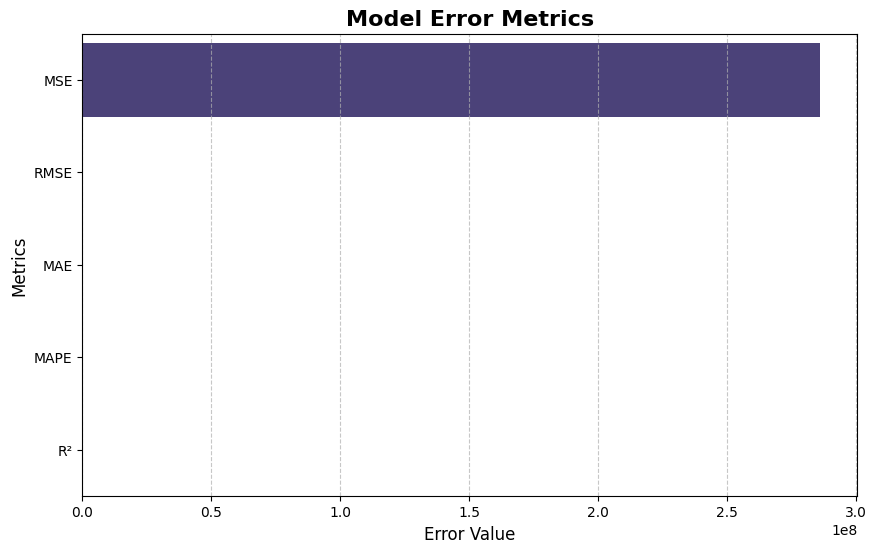

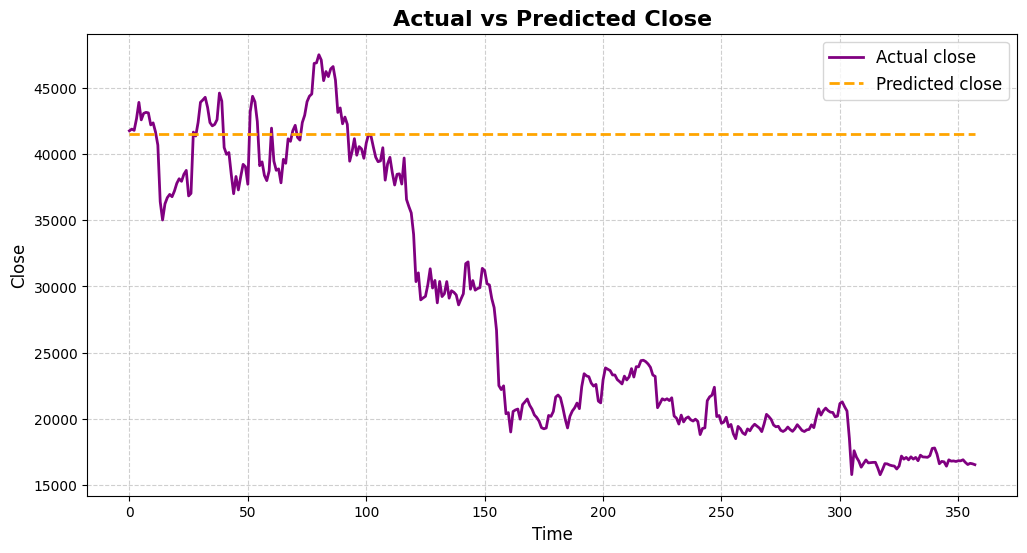

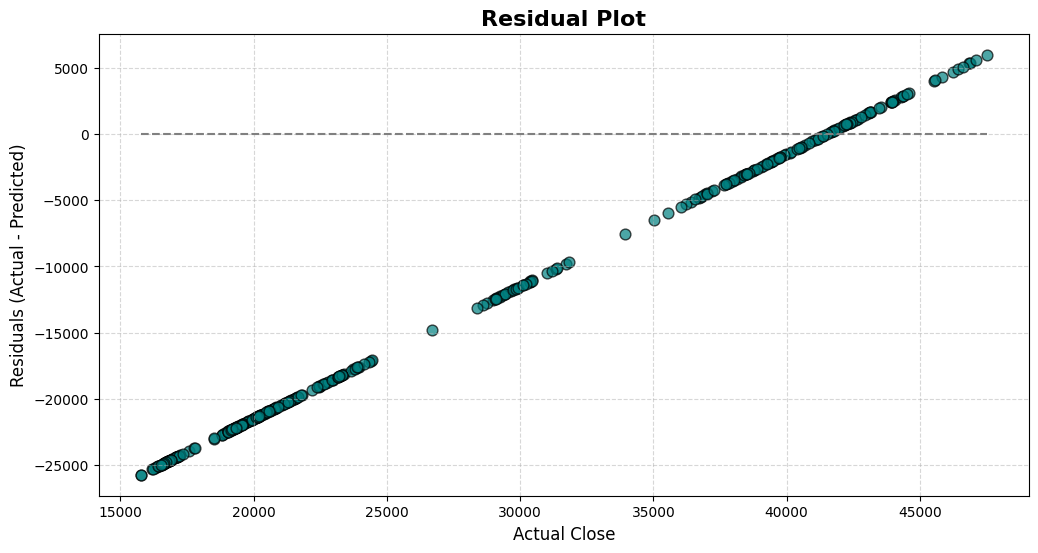

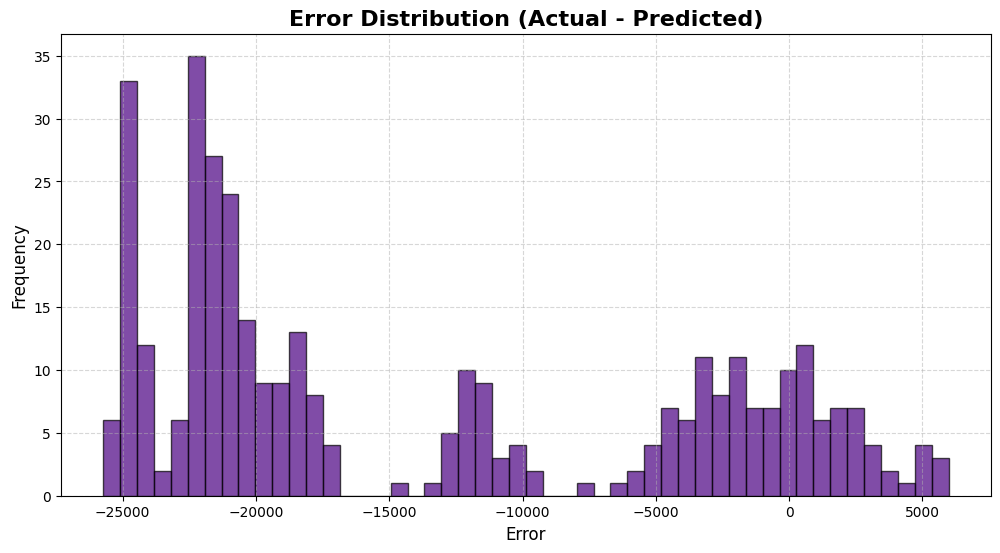

In [25]:
# Output the metrics
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}')
print(f'R² Score: {r2:.4f}')

# Visualization of Metrics (Bar Chart)
metrics = {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape, 'R²': r2}
plt.figure(figsize=(10, 6))
sns.barplot(x=list(metrics.values()), y=list(metrics.keys()), palette='viridis')
plt.title('Model Error Metrics', fontsize=16, fontweight='bold')
plt.xlabel('Error Value', fontsize=12)
plt.ylabel('Metrics', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Visualization: Actual vs Predicted (Line Plot)
plt.figure(figsize=(12, 6))
plt.plot(y_test_original, label='Actual close', color='purple', linewidth=2)
plt.plot(predictions_original, label='Predicted close', color='orange', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted Close', fontsize=16, fontweight='bold')
plt.xlabel('Time', fontsize=12)
plt.ylabel('Close', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Residual Plot
residuals = y_test_original - predictions_original
plt.figure(figsize=(12, 6))
plt.scatter(y_test_original, residuals, color='teal', edgecolor='black', alpha=0.7, s=60)
plt.hlines(y=0, xmin=y_test_original.min(), xmax=y_test_original.max(), color='gray', linestyle='--', linewidth=1.5)
plt.title('Residual Plot', fontsize=16, fontweight='bold')
plt.xlabel('Actual Close', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Error Distribution (Histogram)
errors = y_test_original - predictions_original
plt.figure(figsize=(12, 6))
plt.hist(errors, bins=50, color='indigo', edgecolor='black', alpha=0.7)
plt.title('Error Distribution (Actual - Predicted)', fontsize=16, fontweight='bold')
plt.xlabel('Error', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()